Dataset link

https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import  re
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

In [2]:
print('cuda ', torch.cuda.is_available())
print('gpu ', torch.cuda.get_device_name(0))

cuda  True
gpu  NVIDIA GeForce GTX 1050


#### EDA

In [5]:
fake = pd.read_csv('../data/fake_news/Fake.csv/Fake.csv')
true = pd.read_csv('../data/fake_news/True.csv/True.csv')
fake.head(15)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017"
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017"
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017"
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017"
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017"


In [6]:
true.head(15)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
5,"White House, Congress prepare for talks on spe...","WEST PALM BEACH, Fla./WASHINGTON (Reuters) - T...",politicsNews,"December 29, 2017"
6,"Trump says Russia probe will be fair, but time...","WEST PALM BEACH, Fla (Reuters) - President Don...",politicsNews,"December 29, 2017"
7,Factbox: Trump on Twitter (Dec 29) - Approval ...,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
8,Trump on Twitter (Dec 28) - Global Warming,The following statements were posted to the ve...,politicsNews,"December 29, 2017"
9,Alabama official to certify Senator-elect Jone...,WASHINGTON (Reuters) - Alabama Secretary of St...,politicsNews,"December 28, 2017"


In [7]:
# Labeling target
fake['label']=0
true['label']=1

In [8]:
df = pd.concat([fake, true], ignore_index=True)
df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [9]:
df['date'] = pd.to_datetime(df['date'], dayfirst=False, errors='coerce')

In [10]:
print('\033[44m         Basic statistics         \033[0m\n')

print(f'\033[34mShape\033[0m: {df.shape}\n')
print('\033[34mInfo\033[0m:')
print(df.info())
print('\n\033[34mDescriptive statistics\033[0m:\n',df.describe(include=object))
print('\n\033[34mNumber of news with the same subject\033[0m:\n',df.subject.value_counts())
print(f'\033[34m\nNumber of datetime that are not transformed\033[0m: \n{df.date.isna().value_counts()}')
print('\033[34m\nThe head of the dataset\033[0m:\n')
df.head()

         Basic statistics         

Shape: (44898, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   title    44898 non-null  object        
 1   text     44898 non-null  object        
 2   subject  44898 non-null  object        
 3   date     11868 non-null  datetime64[ns]
 4   label    44898 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 1.7+ MB
None

Descriptive statistics:
                                                     title   text       subject
count                                               44898  44898         44898
unique                                              38729  38646             8
top     Factbox: Trump fills top jobs for his administ...         politicsNews
freq                                                   14    627         11272

Number of news with 

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25,0


In [11]:
df['word_count'] = df['text'].str.split().str.len()
mean_len = df['word_count'].mean()
std_len = df['word_count'].std()
max_seq_len = int(mean_len + 2 * std_len)

print('\033[34mAverage length of words\033[0m: ',mean_len)
print("\033[34mDistribution\033[0m: ", std_len)
print('\033[34mMaximal length text\033[0m: ', max_seq_len)
print('\033[34mDescriptive stats of counts\033[0m: \n',df['word_count'].describe())

Average length of words:  405.28228428883244
Distribution:  351.26559488348715
Maximal length text:  1107
Descriptive stats of counts: 
 count    44898.000000
mean       405.282284
std        351.265595
min          0.000000
25%        203.000000
50%        362.000000
75%        513.000000
max       8135.000000
Name: word_count, dtype: float64


In [12]:
print('\033[34mNumber of duplicates\033[0m: \n', df.duplicated().value_counts())
print('\033[34mNumber of missed values\033[0m: specifics of date transformation \n', df.isna().value_counts())

Number of duplicates: 
 False    44685
True       213
Name: count, dtype: int64
Number of missed values: specifics of date transformation 
 title  text   subject  date   label  word_count
False  False  False    True   False  False         33030
                       False  False  False         11868
Name: count, dtype: int64


### Modeling

#### Model set

In [13]:
#for models
X_y=df[['text','label']].copy()

In [17]:
X_y['text'][1]

'house intelligence committee chairman devin nunes is going to have a bad day he s been under the assumption like many of us that the christopher steele dossier was what prompted the russia investigation so he s been lashing out at the department of justice and the fbi in order to protect trump as it happens the dossier is not what started the investigation according to documents obtained by the new york times former trump campaign adviser george papadopoulos was drunk in a wine bar when he revealed knowledge of russian opposition research on hillary clinton on top of that papadopoulos wasn t just a covfefe boy for trump as his administration has alleged he had a much larger role but none so damning as being a drunken fool in a wine bar coffee boys don t help to arrange a new york meeting between trump and president abdel fattah el sisi of egypt two months before the election it was known before that the former aide set up meetings with world leaders for trump but team trump ran with h

#### Tokenization, encode, padding / truncation, set split

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_y.loc[:,"text"] = X_y["text"].apply(clean_text)
tokenizer = get_tokenizer('basic_english')

def yield_tokens(data):
    for text in data:
        yield tokenizer(text)
vocab = build_vocab_from_iterator(yield_tokens(X_y['text']), specials=['<pad>','<unk>'])
vocab.set_default_index(vocab['<unk>'])

# max_len = int(mean_len +(2*std_len))
max_len = int(mean_len+10)

def encode(text):
    ids = vocab(tokenizer(text))
    return torch.tensor(ids[:max_len])
encoded = [encode(t) for t in X_y['text']]

X=pad_sequence(encoded, batch_first=True, padding_value=vocab['<pad>'])
y=torch.tensor(df['label'].values)

class Text(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Xtr, Xtemp, ytr, ytemp = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

# 10% val, 10% test
Xval, Xte, yval, yte = train_test_split(Xtemp, ytemp, train_size=0.5, stratify=ytemp, random_state=42)

tr_ds = Text(Xtr, ytr)
val_ds = Text(Xval, yval)
te_ds = Text(Xte, yte)

tr_loader = DataLoader(tr_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
te_loader = DataLoader(te_ds, batch_size=64)

#### RNN, LSTM, BILSTM, CNN with with adaptive max pooling

In [19]:
device = torch.device('cuda')

class RNN(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=128, n_classes=2, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.rnn = nn.RNN(emb, hid, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hid, n_classes)
    def forward(self, x):
        x= self.emb(x)
        _, h = self.rnn(x)
        h = self.dropout(h[-1])
        out=self.fc(h)
        return out
class LSTM(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=256, n_classes=2, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, dropout=0.5, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hid, n_classes)
    def forward(self, x):
        x = self.emb(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out
class BILSTM(nn.Module):
    def __init__(self, vocab_size, emb=128, hid=128, n_classes=2, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size,  emb, padding_idx=0)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True, dropout=0.5, num_layers=2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hid*2, n_classes)
    def forward(self, x):
        x = self.emb(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out
class CNN(nn.Module):
    def __init__(self, vocab_size, emb=128, n_classes=2, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb, padding_idx=0)
        self.conv = nn.Conv1d(emb, 256, kernel_size=5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, n_classes)
    def forward(self, x):
        x = self.emb(x).transpose(1,2)
        x = torch.relu(self.conv(x))
        x = self.pool(x).squeeze(-1)
        x = self.dropout(x)
        out = self.fc(x)
        return out

#### Training, testing

In [20]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0,0,0

    for x, y in loader:
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1)==y).sum().item()
        total+=y.size(0)
    return total_loss / total, correct/total
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total= 0.0,0,0
    preds, labels = [],[]
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss=criterion(out,y)
            total_loss += loss.item()
            correct += (out.argmax(1)==y).sum().item()
            total += y.size(0)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.cpu().numpy())
    return total_loss/total, correct/total, labels, preds
def train_model(model, epochs=10):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=10**-3, weight_decay=10**-4)
    crit = nn.CrossEntropyLoss()

    trl, tra, tel, tea = [], [], [], []

    for epoch in range(epochs):
        l, a = train_epoch(model, tr_loader, opt, crit)
        vl, va, labels, preds = eval_epoch(model, te_loader, crit)

        trl.append(l) 
        tra.append(a)
        tel.append(vl) 
        tea.append(va)
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {l:.4f}, Acc: {a:.4f} | "
              f"Val Loss: {vl:.4f}, Acc: {va:.4f}")

    return trl, tra, tel, tea

In [21]:
models = {
    'RNN':RNN(vocab_size=len(vocab)),
    'LSTM':LSTM(vocab_size=len(vocab)),
    'BILSTM':BILSTM(vocab_size=len(vocab)),
    'CNN':CNN(vocab_size=len(vocab))
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    trl, tra, tel, tea = train_model(model, epochs=6)
    test_loss, test_acc, labels, preds = eval_epoch(
        model, te_loader, nn.CrossEntropyLoss()
    )
    results[name] = {
        "model": model,
        "train_losses": trl,
        "train_accs": tra,
        "test_losses": tel,
        "test_accs": tea,
        "labels": labels,
        "preds": preds
    }

Training RNN...
Epoch 01 | Train Loss: 0.0105, Acc: 0.5902 | Val Loss: 0.0089, Acc: 0.7405
Epoch 02 | Train Loss: 0.0107, Acc: 0.5531 | Val Loss: 0.0110, Acc: 0.5274
Epoch 03 | Train Loss: 0.0110, Acc: 0.5157 | Val Loss: 0.0110, Acc: 0.4846
Epoch 04 | Train Loss: 0.0107, Acc: 0.5848 | Val Loss: 0.0089, Acc: 0.7523
Epoch 05 | Train Loss: 0.0088, Acc: 0.7530 | Val Loss: 0.0088, Acc: 0.7530
Epoch 06 | Train Loss: 0.0089, Acc: 0.7428 | Val Loss: 0.0089, Acc: 0.7490
Training LSTM...
Epoch 01 | Train Loss: 0.0094, Acc: 0.6909 | Val Loss: 0.0093, Acc: 0.7238
Epoch 02 | Train Loss: 0.0098, Acc: 0.6545 | Val Loss: 0.0098, Acc: 0.6374
Epoch 03 | Train Loss: 0.0094, Acc: 0.6804 | Val Loss: 0.0109, Acc: 0.5884
Epoch 04 | Train Loss: 0.0109, Acc: 0.5135 | Val Loss: 0.0109, Acc: 0.5229
Epoch 05 | Train Loss: 0.0108, Acc: 0.5196 | Val Loss: 0.0109, Acc: 0.5229
Epoch 06 | Train Loss: 0.0107, Acc: 0.5325 | Val Loss: 0.0099, Acc: 0.5904
Training BILSTM...
Epoch 01 | Train Loss: 0.0096, Acc: 0.6721 | Val

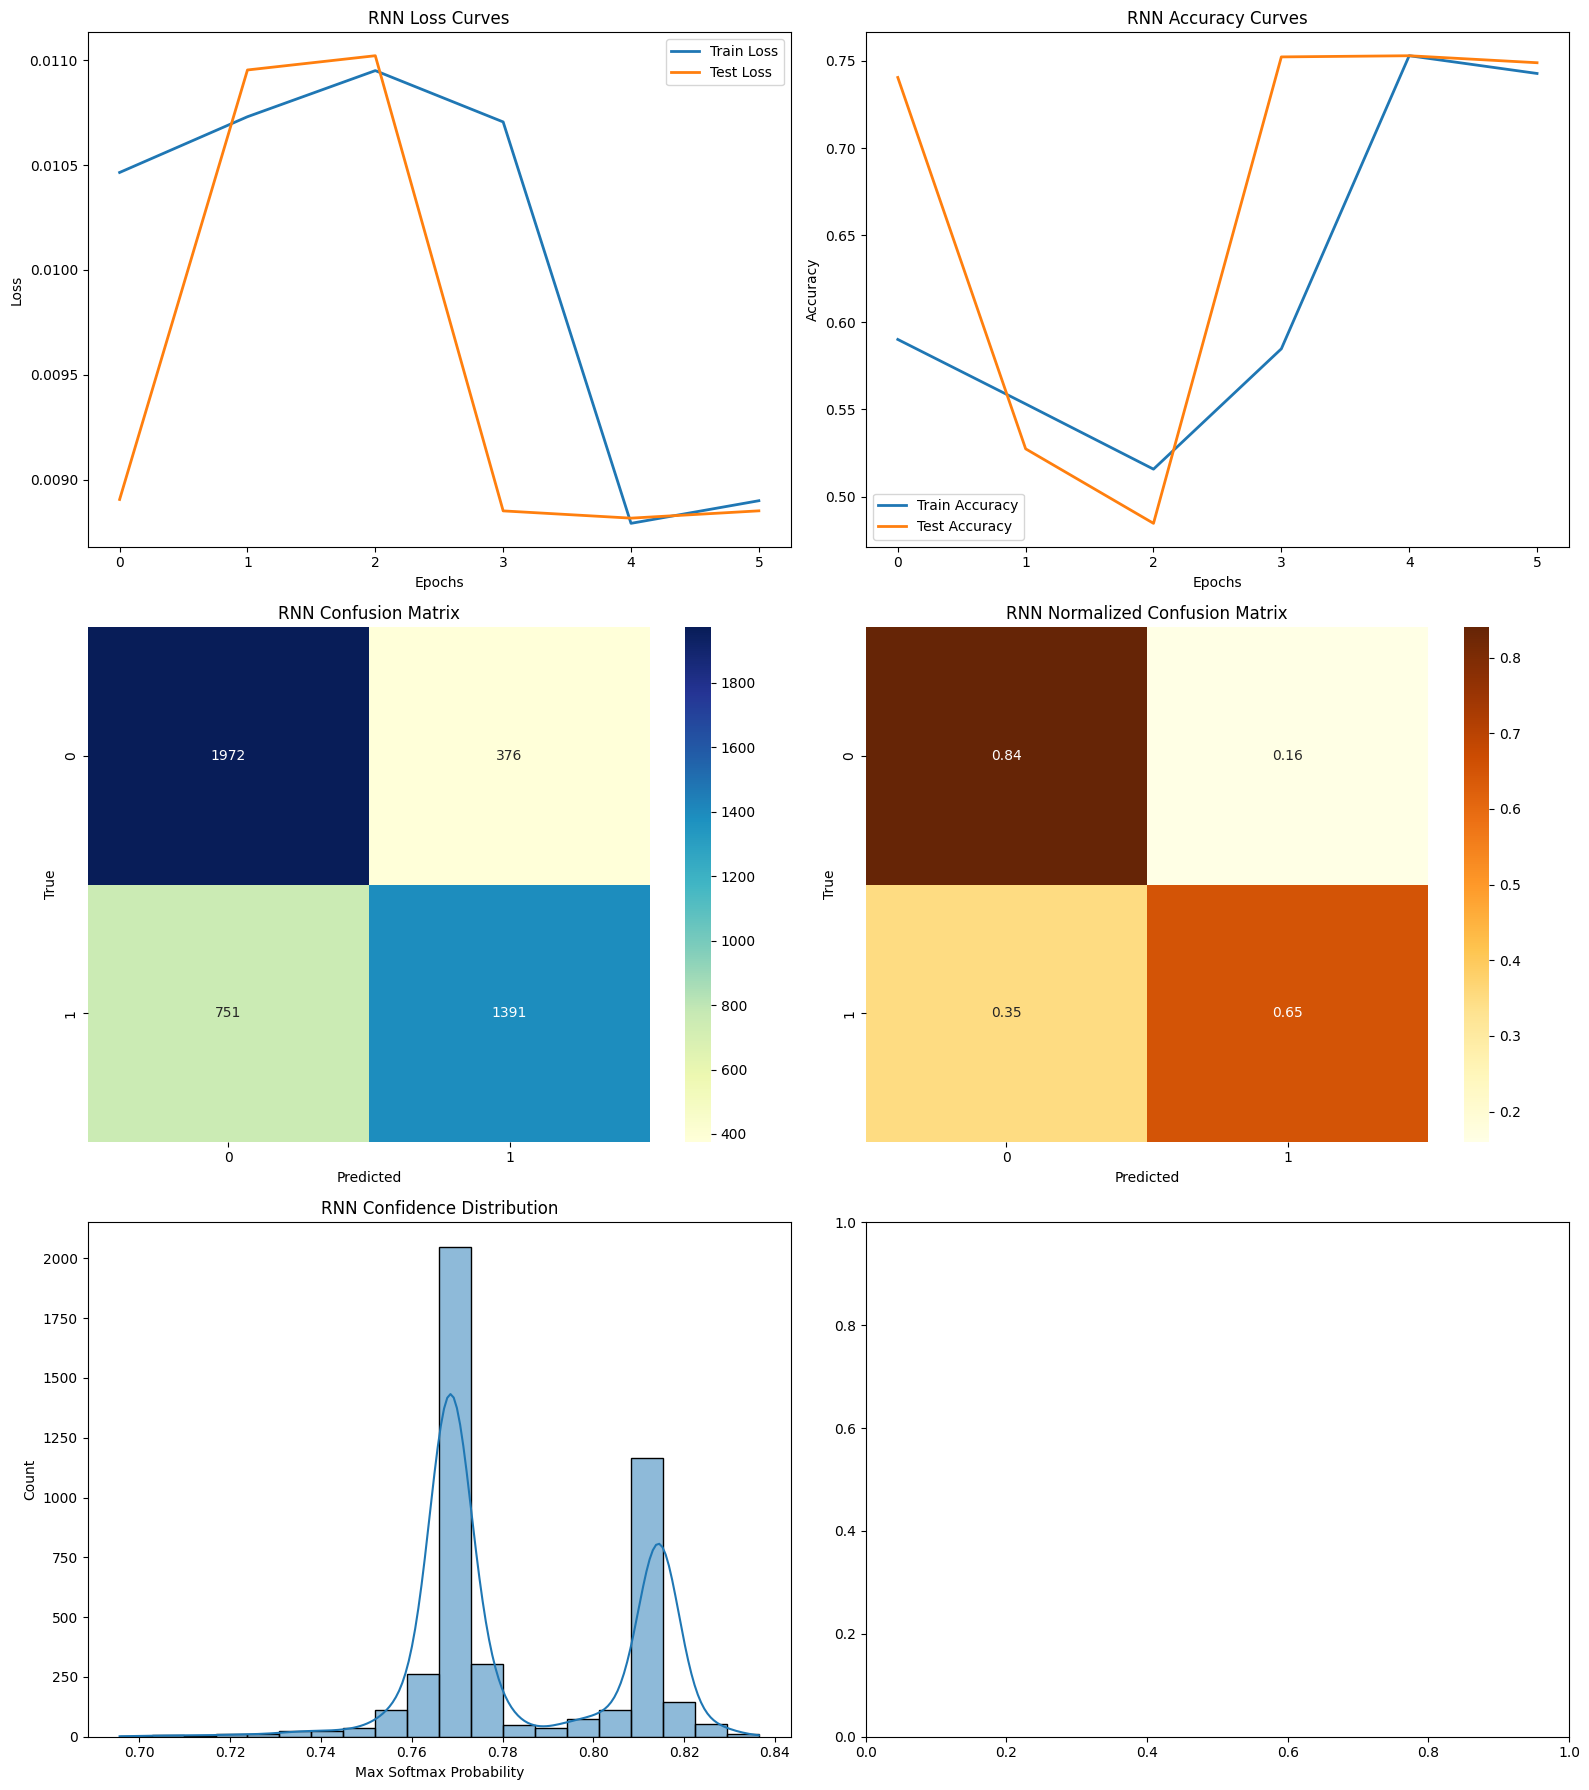


RNN Classification Report
              precision    recall  f1-score   support

        Fake       0.72      0.84      0.78      2348
        Real       0.79      0.65      0.71      2142

    accuracy                           0.75      4490
   macro avg       0.76      0.74      0.74      4490
weighted avg       0.75      0.75      0.75      4490

RNN model saved for Netron


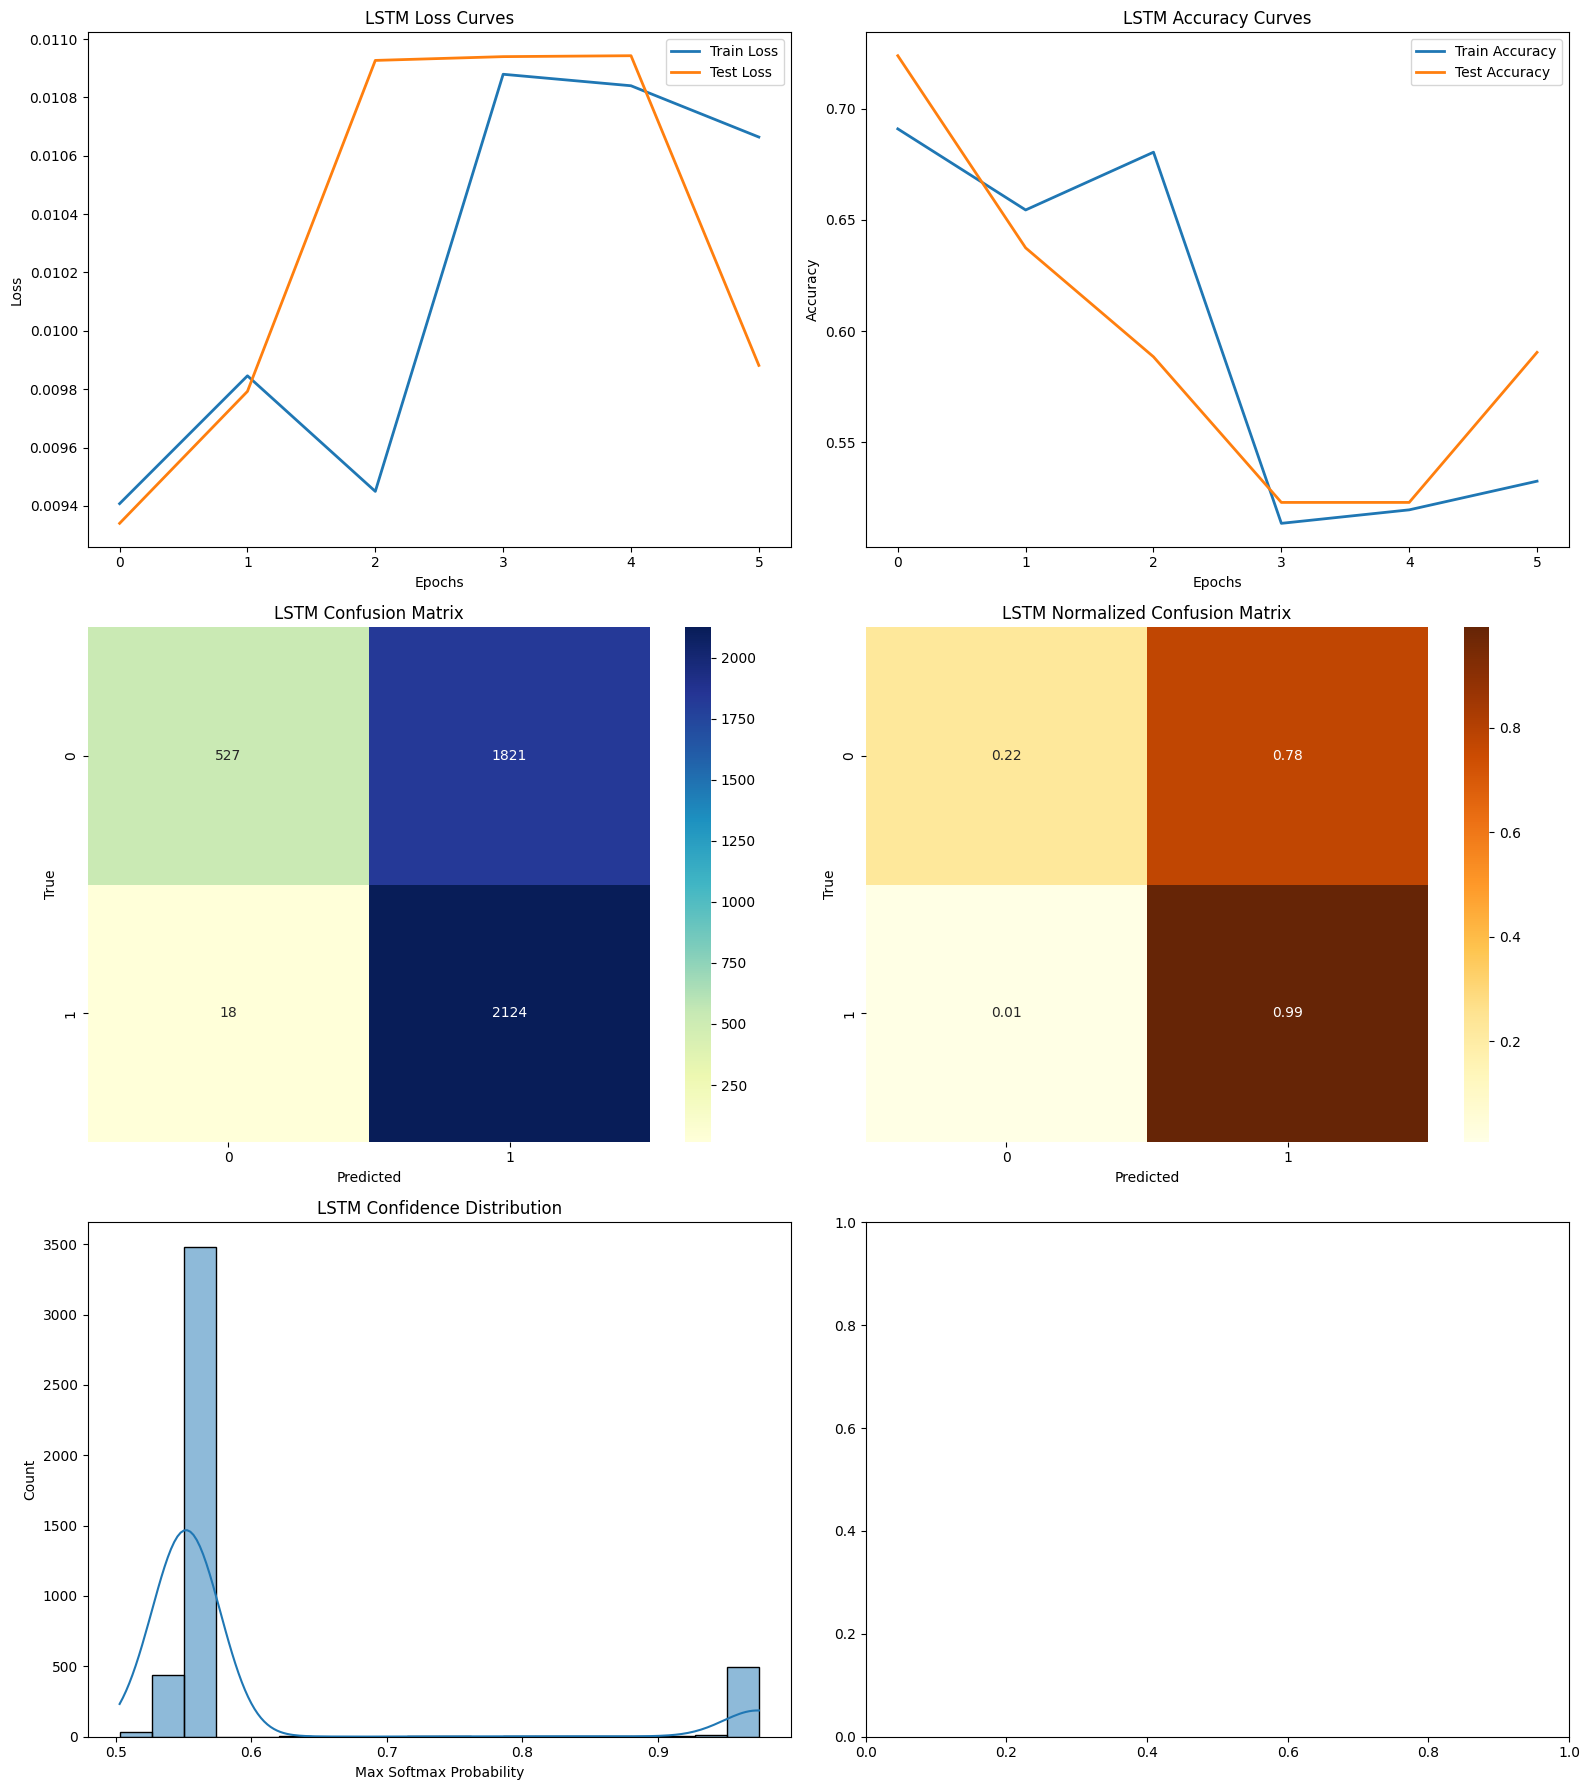


LSTM Classification Report
              precision    recall  f1-score   support

        Fake       0.97      0.22      0.36      2348
        Real       0.54      0.99      0.70      2142

    accuracy                           0.59      4490
   macro avg       0.75      0.61      0.53      4490
weighted avg       0.76      0.59      0.52      4490

LSTM model saved for Netron


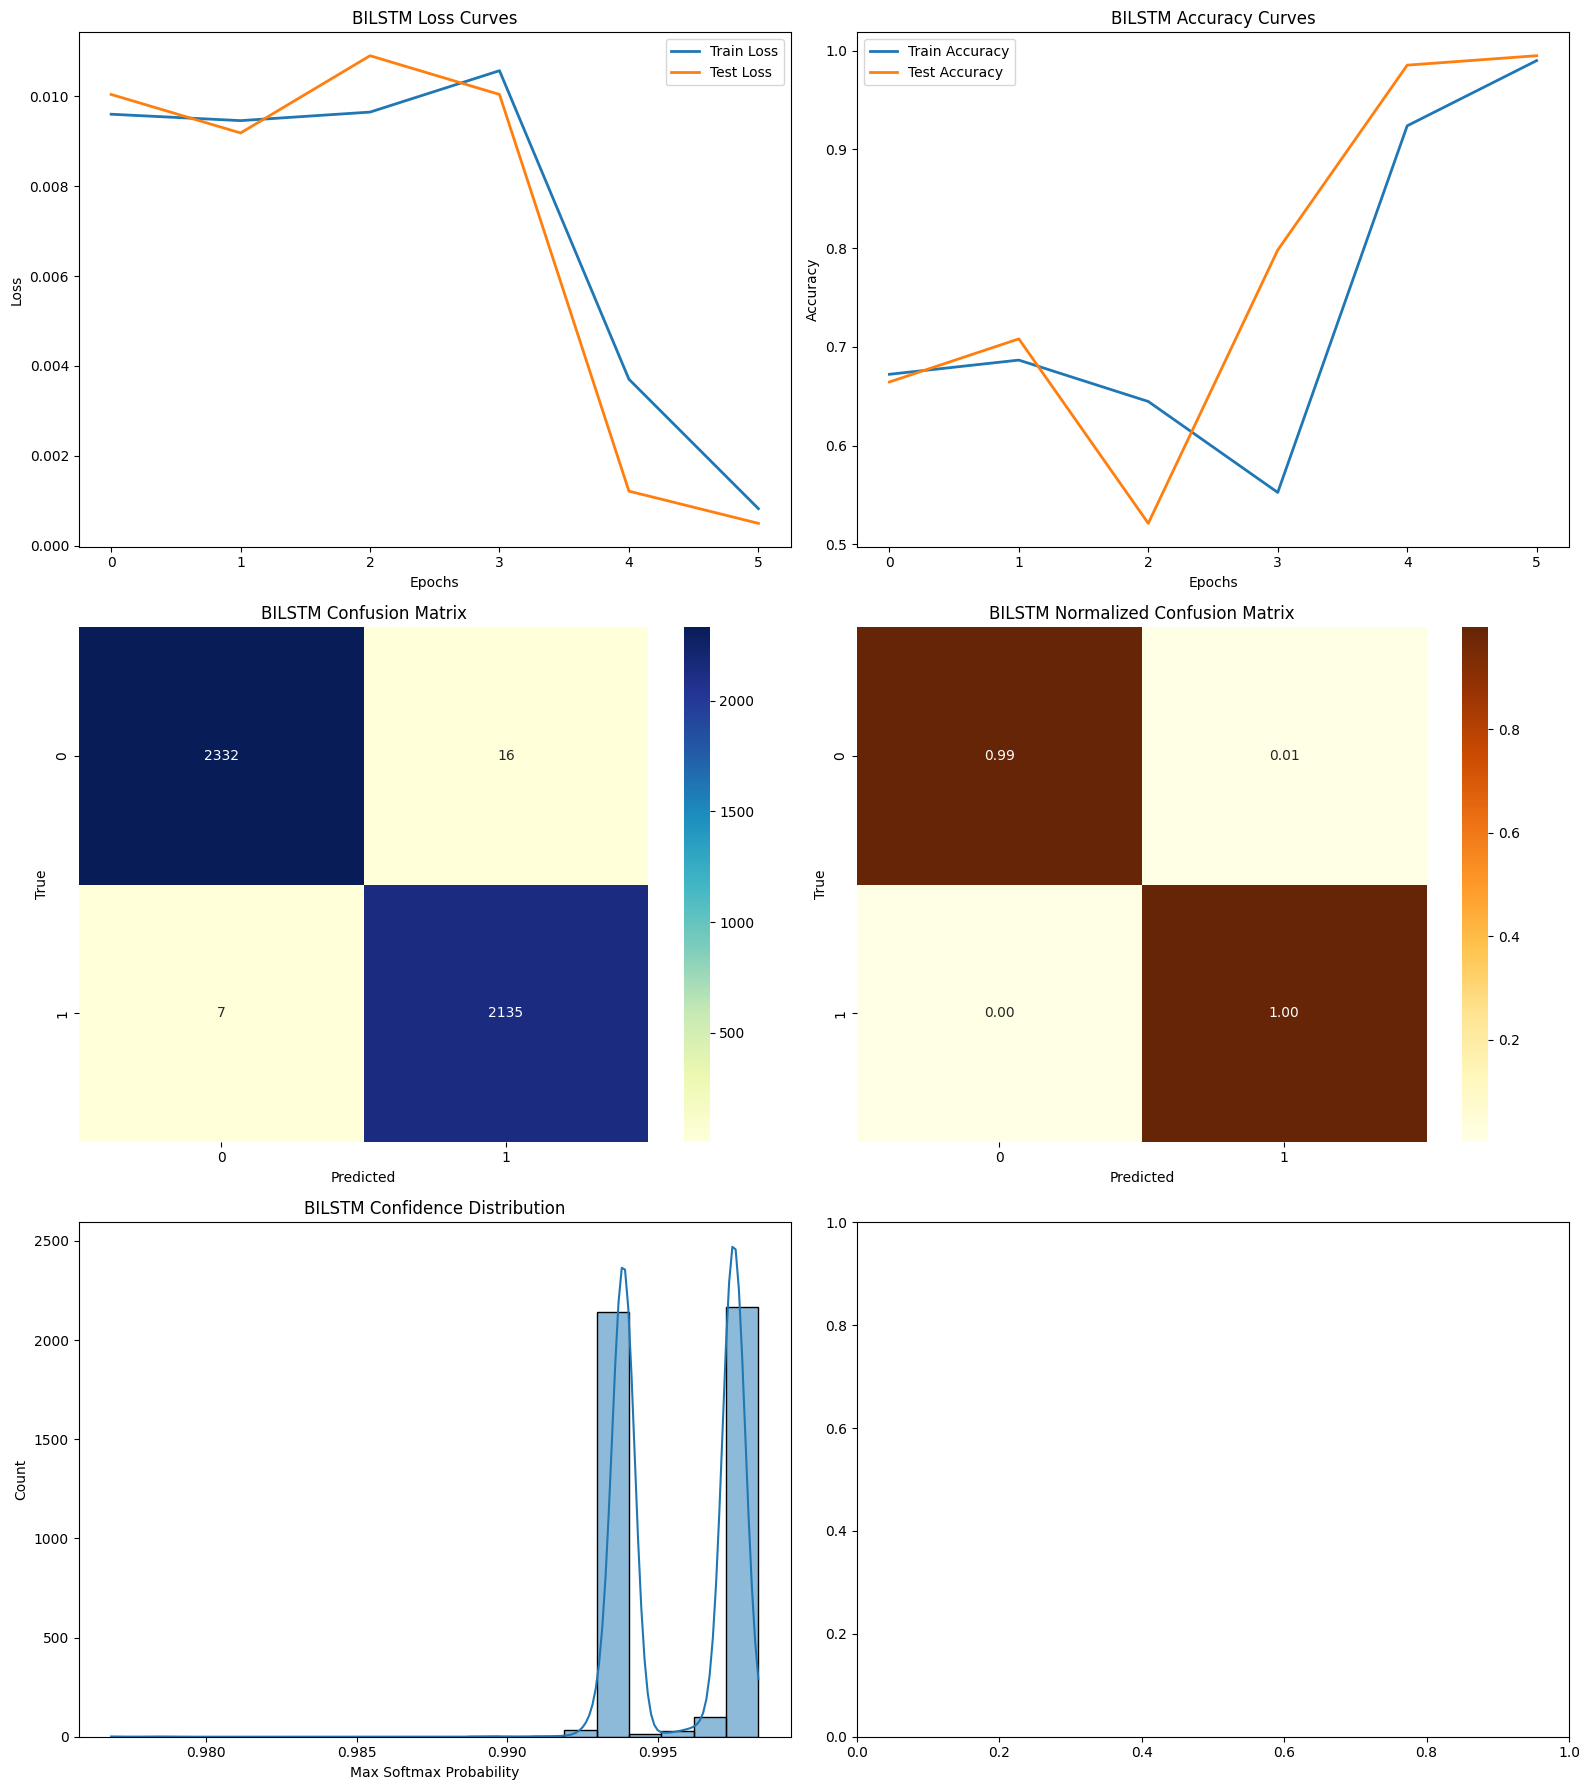


BILSTM Classification Report
              precision    recall  f1-score   support

        Fake       1.00      0.99      1.00      2348
        Real       0.99      1.00      0.99      2142

    accuracy                           0.99      4490
   macro avg       0.99      0.99      0.99      4490
weighted avg       0.99      0.99      0.99      4490

BILSTM model saved for Netron


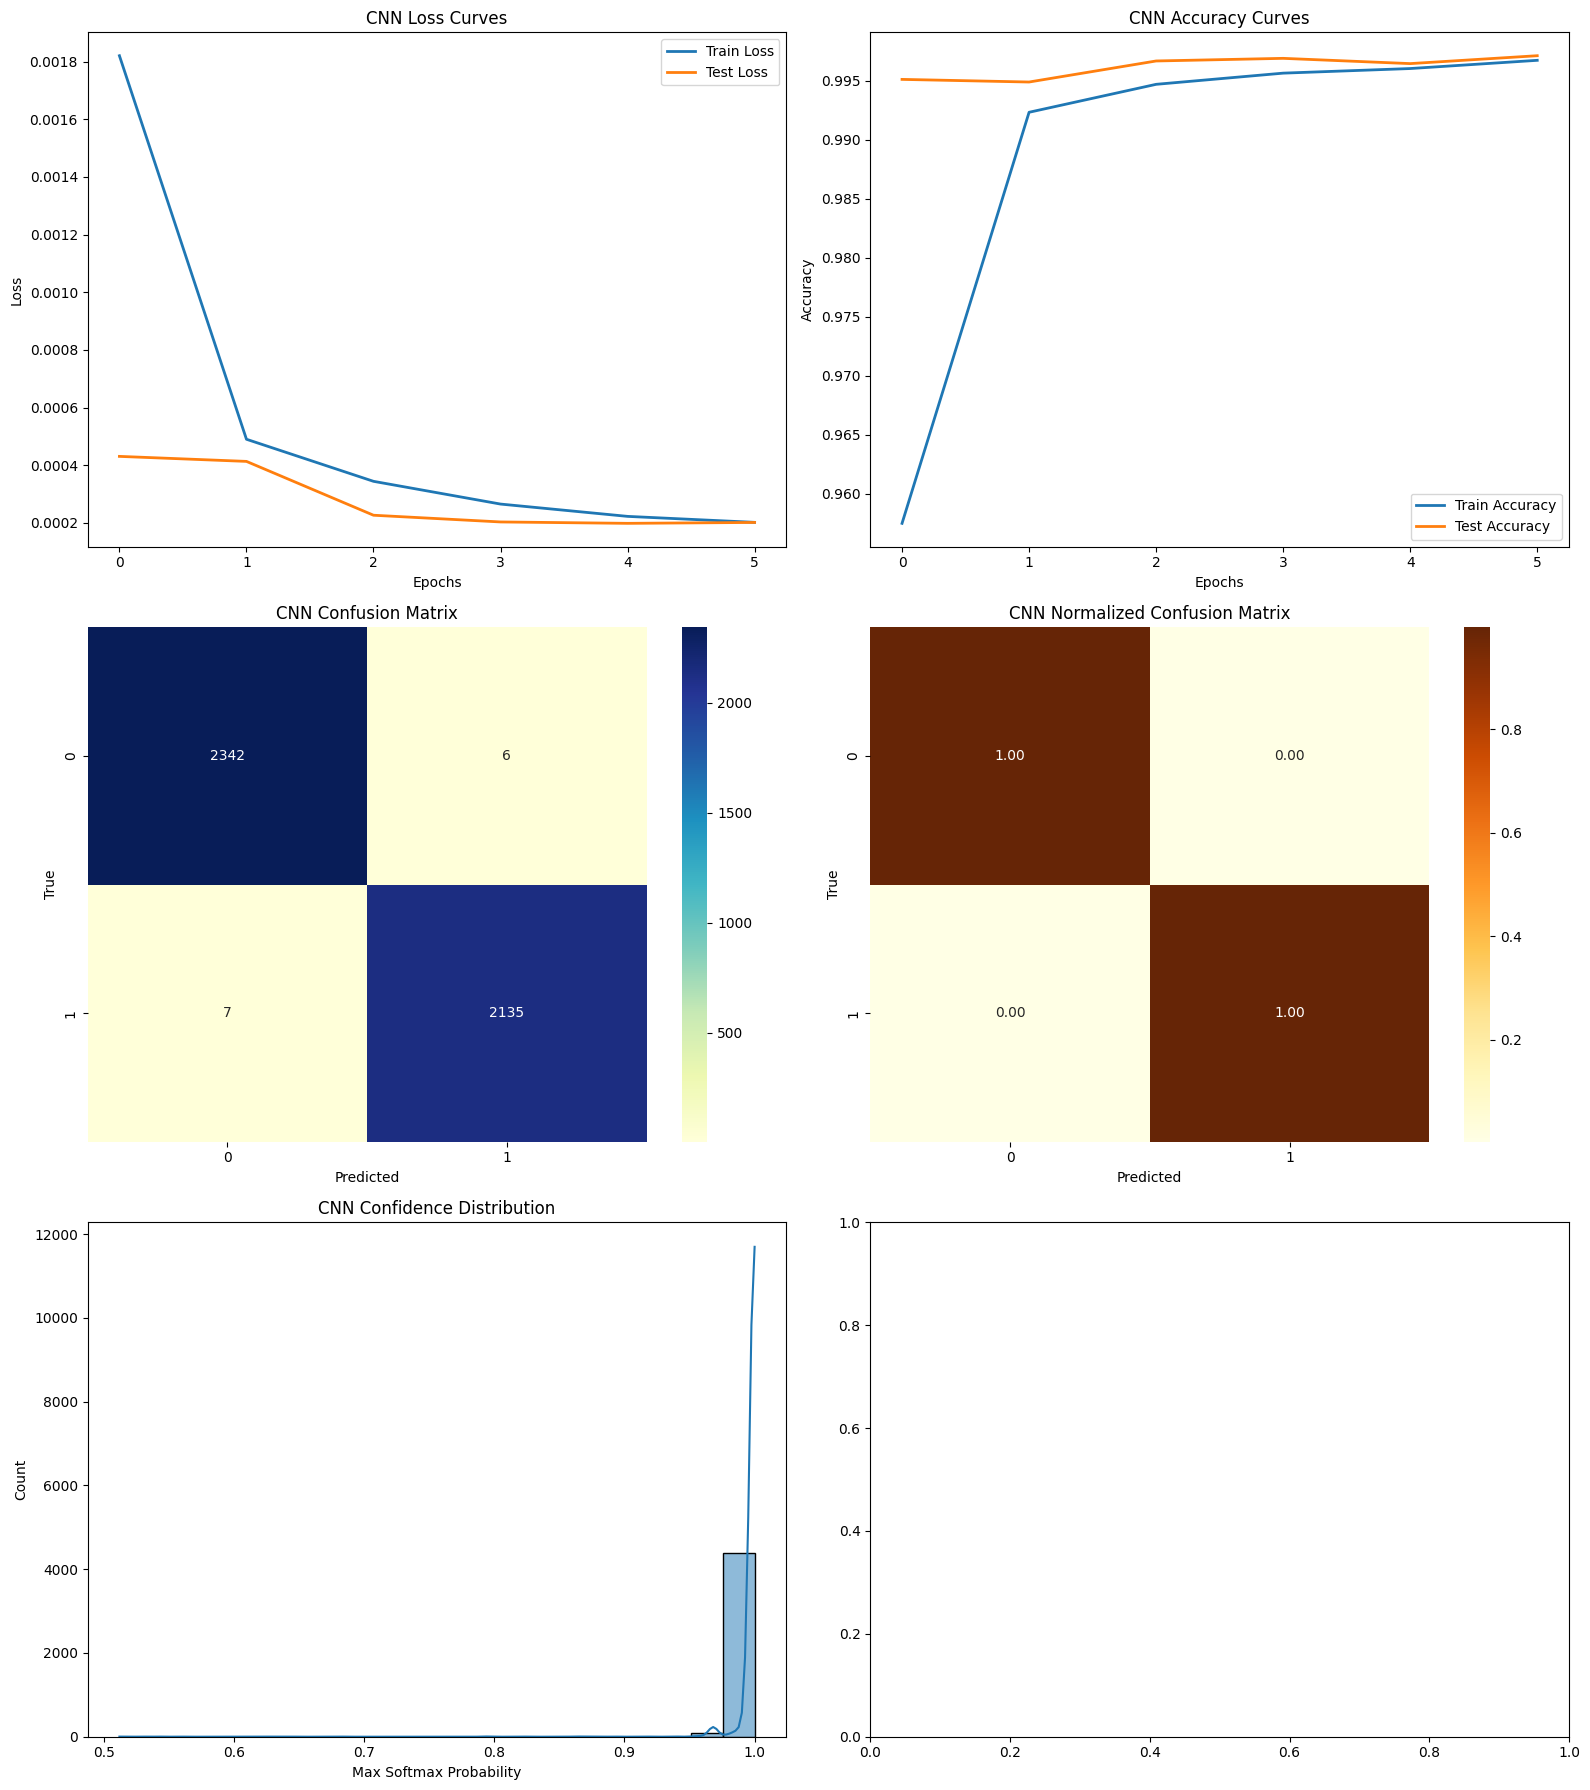


CNN Classification Report
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2348
        Real       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490

CNN model saved for Netron


In [22]:
def visualize_model(name, res):
    model = res["model"]
    trl, tra, tel, tea = res["train_losses"], res["train_accs"], res["test_losses"], res["test_accs"]
    labels, preds = res["labels"], res["preds"]

    fig, axes = plt.subplots(3, 2, figsize=(16,18))
    axes = axes.flatten()
    
    # Loss
    axes[0].plot(trl, label="Train Loss", linewidth=2)
    axes[0].plot(tel, label="Test Loss", linewidth=2)
    axes[0].set_title(f"{name} Loss Curves")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    # Accuracy
    axes[1].plot(tra, label="Train Accuracy", linewidth=2)
    axes[1].plot(tea, label="Test Accuracy", linewidth=2)
    axes[1].set_title(f"{name} Accuracy Curves")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", ax=axes[2])
    axes[2].set_title(f"{name} Confusion Matrix")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("True")

    # Normalized CM
    sns.heatmap(cm/cm.sum(axis=1, keepdims=True), annot=True, fmt=".2f", cmap="YlOrBr", ax=axes[3])
    axes[3].set_title(f"{name} Normalized Confusion Matrix")
    axes[3].set_xlabel("Predicted")
    axes[3].set_ylabel("True")

    # Confidence distribution
    probs=[]
    model.eval()
    with torch.no_grad():
        for x,_ in te_loader:
            x = x.to(device)
            out = model(x)
            p = torch.softmax(out, dim=1).max(dim=1)[0]
            probs.extend(p.cpu().numpy())
    sns.histplot(probs, bins=20, kde=True, ax=axes[4])
    axes[4].set_title(f"{name} Confidence Distribution")
    axes[4].set_xlabel("Max Softmax Probability")
    axes[4].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

    print(f"\n{name} Classification Report")
    print(classification_report(labels, preds, target_names=["Fake","Real"]))


    example = torch.randint(0, len(vocab), (1, max_len)).to(device)
    traced = torch.jit.trace(model, example)
    traced.save(f"{name.lower()}_text_model_netron.pt")
    print(f"{name} model saved for Netron")

for name, res in results.items():
    visualize_model(name, res)